<a href="https://colab.research.google.com/github/vijaygoyal00/Facial-Emotion-Recognition-tool-for-ASD-patients/blob/main/CAPSNET_model_final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Found 1199 files belonging to 6 classes.
Found 226 files belonging to 6 classes.
Classes: ['Natural', 'anger', 'fear', 'joy', 'sadness', 'surprise']
Num classes: 6


Model: "CapsNet_Research"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_images (InputLayer)       │ (None, 48, 48, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1 (Conv2D)                  │ (None, 48, 48, 64)     │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 48, 48, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv2D)                  │ (None, 24, 24, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 24, 24, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3 (Conv2D)                  │ (None, 12, 12, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_1 (Reshape)             │ (None, 1152, 8)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ primary_capsules (Lambda)       │ (None, 1152, 8)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ digit_capsules                  │ (None, 6, 16)          │       884,736 │
│ (DigitCapsuleLayer)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ capsule_lengths (Lambda)        │ (None, 6)              │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,255,168 (4.79 MB)

 Trainable params: 1,254,784 (4.79 MB)

 Non-trainable params: 384 (1.50 KB)

Epoch 1/40
38/38 ━━━━━━━━━━━━━━━━━━━━ 422s 11s/step - accuracy: 0.2402 - loss: 0.4674 - val_accuracy: 0.1593 - val_loss: 0.8073 - learning_rate: 3.0000e-04
Epoch 2/40
38/38 ━━━━━━━━━━━━━━━━━━━━ 33s 853ms/step - accuracy: 0.4395 - loss: 0.3753 - val_accuracy: 0.1593 - val_loss: 0.7397 - learning_rate: 3.0000e-04
Epoch 3/40
38/38 ━━━━━━━━━━━━━━━━━━━━ 33s 848ms/step - accuracy: 0.6430 - loss: 0.3024 - val_accuracy: 0.1593 - val_loss: 0.6285 - learning_rate: 3.0000e-04
Epoch 4/40
38/38 ━━━━━━━━━━━━━━━━━━━━ 40s 846ms/step - accuracy: 0.7882 - loss: 0.2364 - val_accuracy: 0.1593 - val_loss: 0.5473 - learning_rate: 3.0000e-04
Epoch 5/40
38/38 ━━━━━━━━━━━━━━━━━━━━ 33s 853ms/step - accuracy: 0.8657 - loss: 0.1829 - val_accuracy: 0.1947 - val_loss: 0.5493 - learning_rate: 3.0000e-04
Epoch 6/40
38/38 ━━━━━━━━━━━━━━━━━━━━ 34s 878ms/step - accuracy: 0.9091 - loss: 0.1461 - val_accuracy: 0.2124 - val_loss: 0.5406 - learning_rate: 3.0000e-04
Epoch 7/40
38/38 ━━━━━━━━━━━━━━━━━━━━ 32s 847ms/step - accu

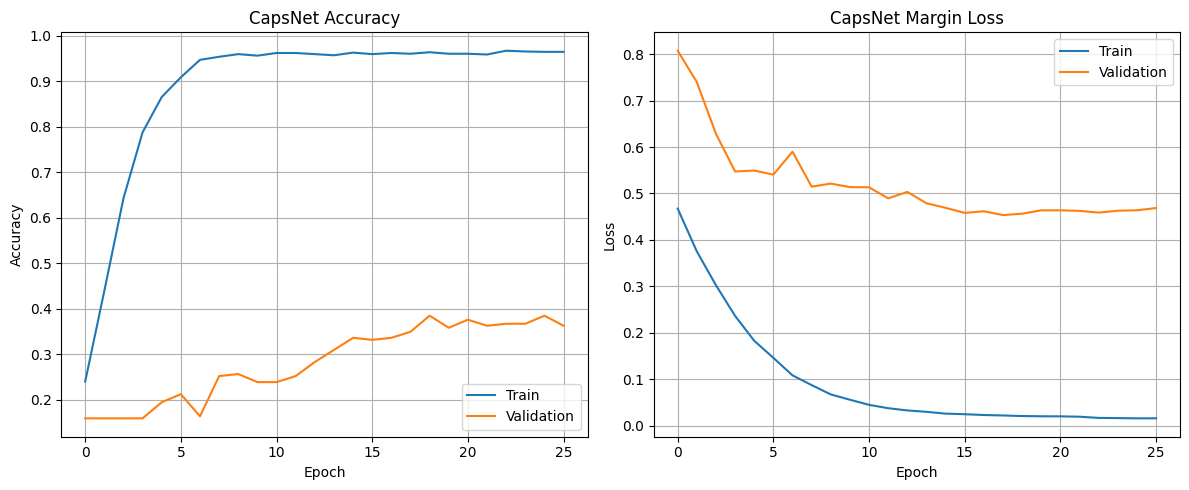

Model saved successfully.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import tensorflow as tf
from tensorflow.keras import layers, models, losses
import matplotlib.pyplot as plt
import os

# CONFIG

DATASET_BASE_PATH = '/content/drive/MyDrive/Autism emotion recogition dataset'
IMG_SIZE = (48, 48)
BATCH_SIZE = 32
NUM_CLASSES = 6
EPOCHS = 40
ROUTINGS = 3

train_path = os.path.join(DATASET_BASE_PATH, 'train')
test_path  = os.path.join(DATASET_BASE_PATH, 'test')

# LOAD DATA

train_ds = tf.keras.utils.image_dataset_from_directory(
    train_path,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    color_mode='grayscale',
    label_mode='int',
    shuffle=True,
    seed=42
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    test_path,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    color_mode='grayscale',
    label_mode='int',
    shuffle=False
)

class_names = train_ds.class_names
print("Classes:", class_names)
print("Num classes:", len(class_names))

def normalize(x, y):
    x = tf.cast(x, tf.float32) / 255.0
    return x, y

train_ds = train_ds.map(normalize).prefetch(tf.data.AUTOTUNE)
test_ds  = test_ds.map(normalize).prefetch(tf.data.AUTOTUNE)


# MARGIN LOSS

class MarginLoss(losses.Loss):
    def __init__(self, m_plus=0.9, m_minus=0.1, lambda_=0.5):
        super().__init__()
        self.m_plus = m_plus
        self.m_minus = m_minus
        self.lambda_ = lambda_

    def call(self, y_true, y_pred):
        y_true_onehot = tf.one_hot(tf.cast(y_true, tf.int32), depth=NUM_CLASSES)

        present_loss = y_true_onehot * tf.square(tf.nn.relu(self.m_plus - y_pred))
        absent_loss = (1.0 - y_true_onehot) * tf.square(tf.nn.relu(y_pred - self.m_minus))

        loss = present_loss + self.lambda_ * absent_loss
        return tf.reduce_mean(tf.reduce_sum(loss, axis=1))


# SQUASH FUNCTION

def squash(s, axis=-1):
    squared_norm = tf.reduce_sum(tf.square(s), axis=axis, keepdims=True)
    safe_norm = tf.sqrt(squared_norm + 1e-7)
    scale = squared_norm / (1.0 + squared_norm)
    return scale * s / safe_norm


# DIGIT CAPSULE LAYER

class DigitCapsuleLayer(layers.Layer):
    def __init__(self, num_capsules, capsule_dim, routings=3, **kwargs):
        super().__init__(**kwargs)
        self.num_capsules = num_capsules
        self.capsule_dim = capsule_dim
        self.routings = routings

    def build(self, input_shape):
        num_in_caps = int(input_shape[1])
        in_dim = int(input_shape[2])

        self.W = self.add_weight(
            name='W',
            shape=(num_in_caps, self.num_capsules, in_dim, self.capsule_dim),
            initializer=tf.keras.initializers.HeNormal(),
            trainable=True
        )
        super().build(input_shape)

    def call(self, inputs):
        # inputs: (batch, n_in, in_dim)
        # W:      (n_in, n_out, in_dim, out_dim)
        # u_hat:  (batch, n_in, n_out, out_dim)
        u_hat = tf.einsum('bni,noij->bnoj', inputs, self.W)

        b = tf.zeros(
            shape=(tf.shape(inputs)[0], tf.shape(inputs)[1], self.num_capsules),
            dtype=tf.float32
        )

        for t in range(self.routings):
            c = tf.nn.softmax(b, axis=-1)
            s = tf.reduce_sum(tf.expand_dims(c, -1) * u_hat, axis=1)
            v = squash(s)

            if t < self.routings - 1:
                agreement = tf.reduce_sum(
                    u_hat * tf.expand_dims(v, axis=1),
                    axis=-1
                )
                b = b + agreement

        return v

    def compute_output_shape(self, input_shape):
        return (input_shape[0], self.num_capsules, self.capsule_dim)


# BUILD MODEL

def build_research_capsnet(input_shape, n_classes):
    inputs = layers.Input(shape=input_shape, name='input_images')

    x = layers.Conv2D(64, (3, 3), activation='relu', padding='same', name='conv1')(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2, 2))(x)

    x = layers.Conv2D(128, (3, 3), activation='relu', padding='same', name='conv2')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2, 2))(x)

    x = layers.Conv2D(256, (3, 3), activation='relu', padding='same', name='conv3')(x)
    x = layers.MaxPooling2D((2, 2))(x)

    x = layers.Reshape((-1, 8))(x)
    x = layers.Lambda(squash, name='primary_capsules')(x)

    x = DigitCapsuleLayer(
        num_capsules=n_classes,
        capsule_dim=16,
        routings=ROUTINGS,
        name='digit_capsules'
    )(x)

    lengths = layers.Lambda(
        lambda z: tf.sqrt(tf.reduce_sum(tf.square(z), axis=-1) + 1e-7),
        name='capsule_lengths'
    )(x)

    return models.Model(inputs, lengths, name='CapsNet_Research')

model = build_research_capsnet((48, 48, 1), NUM_CLASSES)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=3e-4),
    loss=MarginLoss(),
    metrics=[tf.keras.metrics.SparseCategoricalAccuracy(name='accuracy')]
)

model.summary()


# CALLBACKS

callbacks = [
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=4,
        min_lr=1e-6,
        verbose=1
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=8,
        restore_best_weights=True,
        verbose=1
    )
]


# TRAIN

history = model.fit(
    train_ds,
    validation_data=test_ds,
    epochs=EPOCHS,
    callbacks=callbacks,
    verbose=1
)


# EVALUATE

test_loss, test_acc = model.evaluate(test_ds, verbose=1)
print(f"\nTest Loss     : {test_loss:.4f}")
print(f"Test Accuracy : {test_acc:.4f}")


# PLOT

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Validation')
plt.title('CapsNet Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Validation')
plt.title('CapsNet Margin Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


# SAVE

model.save(os.path.join(DATASET_BASE_PATH, 'capsnet_research_margin_loss.keras'))
print("Model saved successfully.")
